# 05 — Embedding space analysis

Following feedback from Prof. Vincent, this notebook investigates the geometric 
structure of the ProstT5 embedding space. The goal is to characterize whether the discriminative signal reflects a global geometric separation between oncogenes and tumor suppressors, or a locally exploitable but geometrically diffuse property.




## 1. Setup and data loading

In [10]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import pyarrow.parquet as pq

In [2]:
features = pd.read_parquet("../data/features_baseline_ref.parquet") 
embeddings = np.load("../data/embeddings/prostt5_embeddings.npy")
with open("../data/embeddings/prostt5_accessions.json") as f : 
    accessions_json = json.load(f)
with open("../data/accession_to_cluster.json") as f1 : 
    accession_to_cluster = json.load(f1)

In [3]:
matrice = []
ordered_accessions = []
acc_to_vec = {a: emb for a, emb in zip(accessions_json, embeddings)}
for acc in features['accession']:
    matrice.append(acc_to_vec[acc])
    ordered_accessions.append(acc)
matrice = np.stack(matrice)
print(matrice.shape)
y = features['label'].values
assert ordered_accessions == list(features['accession']), "Désalignement"

(404, 1024)


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_binary= le.fit_transform(y)

## 2. Principal Component Analysis (PCA)

In [5]:
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

pca = PCA(n_components=2)
X_pca = pca.fit_transform(matrice)
print(f"Variance expliquée par les 2 composantes principales : {pca.explained_variance_ratio_.sum():.4f}")
print(f"Corrélation avec la variable binaire :")
print(f"Composante 1 : {pearsonr(X_pca[:, 0], y_binary)[0]:.4f}")
print(f"Composante 2 : {pearsonr(X_pca[:, 1], y_binary)[0]:.4f}")

Variance expliquée par les 2 composantes principales : 0.5512
Corrélation avec la variable binaire :
Composante 1 : 0.0105
Composante 2 : 0.1121


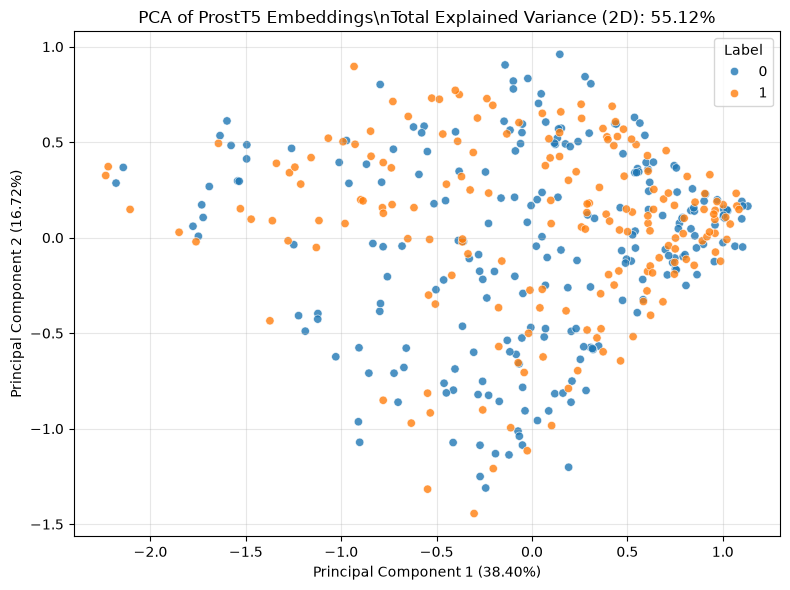

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_binary, palette=['#1f77b4', '#ff7f0e'], alpha=0.8)
plt.title(f"PCA of ProstT5 Embeddings\\nTotal Explained Variance (2D): {pca.explained_variance_ratio_.sum():.2%}")
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%})")
plt.legend(title='Label')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Silhouette analysis (cosine metric)

In [7]:
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_distances

silhouette = silhouette_score(matrice, y, metric='cosine')

# Breakdown intra/inter
distances = cosine_distances(matrice)
# calculer moyenne des distances intra-classe et inter-classe
intra_distances = []
inter_distances = []
for i in range(len(y)):
    for j in range(i + 1, len(y)):
        if y[i] == y[j]:
            intra_distances.append(distances[i, j])
        else:
            inter_distances.append(distances[i, j])
mean_intra_distance = np.mean(intra_distances)
mean_inter_distance = np.mean(inter_distances)

print(f"Silhouette score: {silhouette:.4f}")
print(f"Mean intra-class distance: {mean_intra_distance:.4f}")
print(f"Mean inter-class distance: {mean_inter_distance:.4f}")

Silhouette score: 0.0073
Mean intra-class distance: 0.3640
Mean inter-class distance: 0.3670


This confirms that the discriminative signal exploited by the downstream 
classifier with a F1-score = 0.60 is not a 
global geometric separation between the two classes. The Random Forest 
finds a locally exploitable statistical signal, but this signal is not 
aligned with the global structure of the embedding space.

## 4. UMAP visualization

/Users/florian/dev/projet/Oncolake_TorchProtein/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


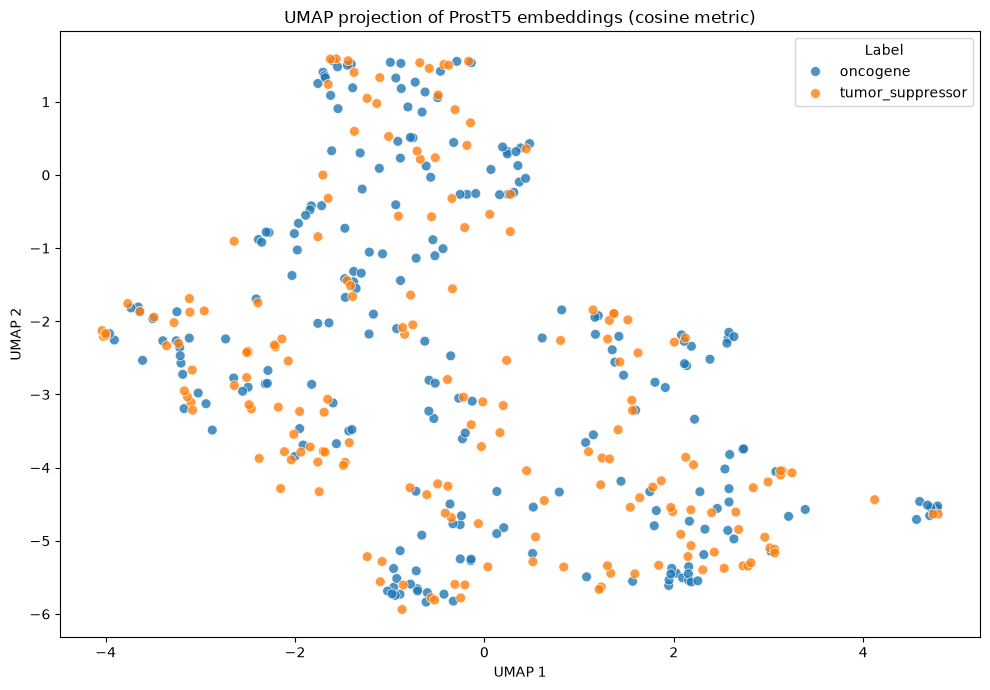

In [ ]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',   
    random_state=42,
)
embedding_2d = reducer.fit_transform(matrice)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=embedding_2d[:, 0], y=embedding_2d[:, 1],
                hue=y, palette=['#1f77b4', '#ff7f0e'], alpha=0.8, s=50)
plt.title('UMAP projection of ProstT5 embeddings (cosine metric)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(title='Label')
plt.tight_layout()
plt.savefig('../results/umap_prostt5.png', dpi=150, bbox_inches='tight')
plt.show()

This visual convergence with the silhouette analysis provides strong evidence that 
the ProstT5 embedding space is not organized around the oncogene/tumor 
suppressor distinction. The sub-clusters visible in the projection reflect 
some other latent property that ProstT5 encodes 
by design and not oncogenicity.

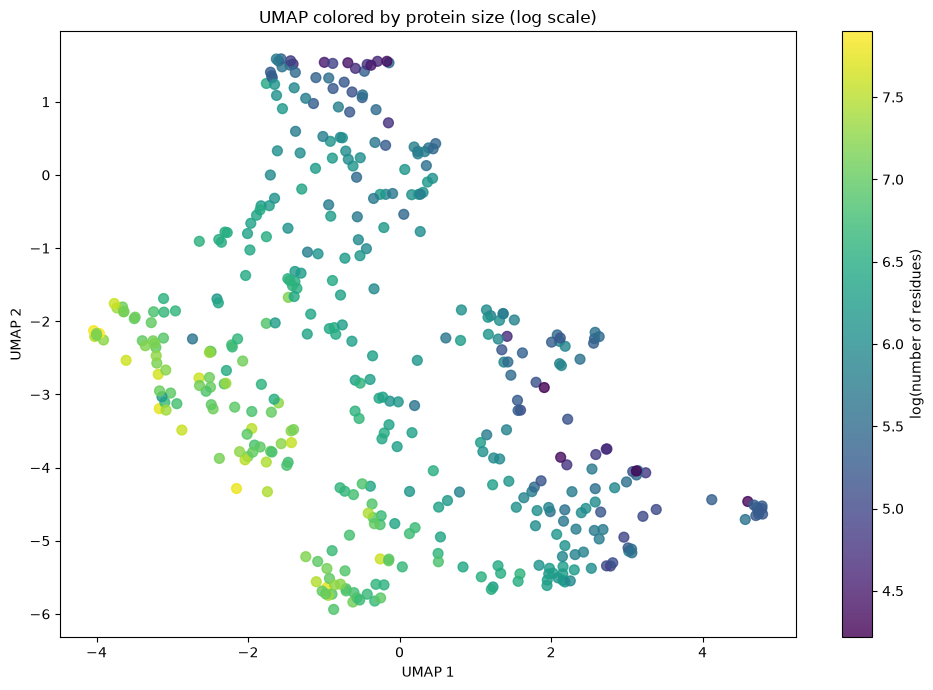

In [12]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1],
                      c=np.log(features['n_residues_structure']),
                      cmap='viridis', alpha=0.8, s=50)
plt.colorbar(scatter, label='log(number of residues)')
plt.title('UMAP colored by protein size (log scale)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.savefig('../results/umap_prostt5_by_size.png', dpi=150, bbox_inches='tight')
plt.show()

Coloring the UMAP by protein size reveals a clear organizational 
axis: small proteins cluster on the right, medium-sized 
 in the center, large proteins on the left. ProstT5 clearly encodes size as one of its latent axes.

In [13]:
import scipy.stats

sizes_oncogene = features[features['label']=='oncogene']['n_residues_structure']
sizes_suppressor = features[features['label']=='tumor_suppressor']['n_residues_structure']

print(f"Oncogenes  : median = {sizes_oncogene.median():.0f} residues, mean = {sizes_oncogene.mean():.0f}")
print(f"Suppressors: median = {sizes_suppressor.median():.0f} residues, mean = {sizes_suppressor.mean():.0f}")

stat, pvalue = scipy.stats.mannwhitneyu(sizes_oncogene, sizes_suppressor)
print(f"\nMann-Whitney U test: p = {pvalue:.4f}")

Oncogenes  : median = 483 residues, mean = 626
Suppressors: median = 519 residues, mean = 659

Mann-Whitney U test: p = 0.5946


## Summary and implications for the main result

## Summary

Three complementary analyses converge on the same conclusion: the ProstT5 
embedding space does not exhibit any global structure that discriminates 
oncogenes from tumor suppressors.

**Key findings (reproducing independent analysis by Prof. Vincent):**
- PCA: 55.1% variance in 2 components, correlations to labels of 0.01 (PC1) and 0.11 (PC2)
- Silhouette cosine: 0.007 
- UMAP by label: visible sub-clusters, but each contains both classes

**Implications for notebook 04's result.** The statistically significant 
discrimination reported in notebook 04 is not driven by a global geometric separation, nor by any simple 
univariate proxy we could identify. The signal is diffuse and multivariate — 
the classifier likely exploits combinations of local structural features that 
ProstT5 encodes but that do not organize the embedding space at the class level. 
Feature importance analysis on the classifier or gradient-based attribution on 
ProstT5 outputs would be needed to identify which specific properties drive 
the discrimination